# Marked Temporal Point Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/marked_from_scratch_and_numpyro.ipynb)

A **marked TPP** pairs each event time $t_i$ with a mark $m_i$. Under the separable factorisation

$$\lambda(t, m) = \lambda_g(t) \cdot f(m \mid t, \mathcal{H}),$$

the joint log-likelihood decomposes:

$$\log L = \log L_\text{ground}(\{t_i\}) + \sum_i \log f(m_i \mid t_i, \mathcal{H}_i).$$

The mark distribution can be any NumPyro `Distribution` — continuous (Normal, Gamma, **GPD** for heavy-tailed marks), multivariate (`MultivariateNormal`), or discrete (`Categorical`). A natural use case for xtremax: marks drawn from a `GeneralizedParetoDistribution` to model storm-event intensities.

This notebook:

1. **From scratch** — use the primitives `marks_log_prob` + ground-process sampler to simulate storm events with diurnal rate and GPD intensity marks.
2. **With NumPyro** — jointly recover the diurnal amplitude, the GPD scale, and the GPD shape $\xi$ with NUTS.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.distributions import GeneralizedParetoDistribution
from xtremax.point_processes.distributions import (
    MarkedTemporalPointProcess as MarkedDist,
)
from xtremax.point_processes.operators import (
    InhomogeneousPoissonProcess,
    MarkedTemporalPointProcess,
    PiecewiseConstantLogIntensity,
)
from xtremax.point_processes.primitives import marks_log_prob


key = random.PRNGKey(0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From Scratch: Simulated Storms

**Ground process**: diurnal IPP with 4 rate bins over a 24-hour window.
**Marks**: GPD intensities whose scale tracks the time-of-day rate.

In [2]:
bin_edges = jnp.array([0.0, 6.0, 12.0, 18.0, 24.0])
rates = jnp.array([0.3, 0.6, 1.2, 0.8])
ipp = InhomogeneousPoissonProcess.from_piecewise_constant(bin_edges, rates)

XI_TRUE = 0.15

def marks_fn_make(amplitude):
    def fn(t, history):
        # Diurnal coupling: stronger storms when the ground rate is higher.
        scale_t = 0.5 + amplitude * (jnp.sin(2 * jnp.pi * (t - 6.0) / 24.0) + 1.0)
        return GeneralizedParetoDistribution(scale=scale_t, concentration=XI_TRUE)
    return fn


mtpp = MarkedTemporalPointProcess(
    ground=ipp,
    mark_distribution_fn=marks_fn_make(amplitude=0.8),
    mark_dim=None,
    history_at_each_event=False,
)

times, mask, marks = mtpp.sample(random.PRNGKey(1), max_events=512)
print(f"n events = {int(jnp.sum(mask))}")

n events = 18


Events + marks overlay on top of the piecewise-constant ground intensity.

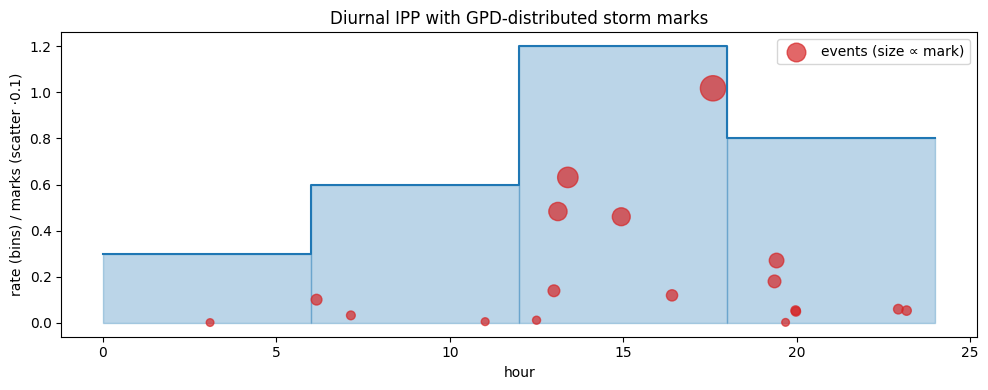

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for a, b, r in zip(bin_edges[:-1], bin_edges[1:], rates):
    ax.fill_between([a, b], 0, r, color="C0", alpha=0.3)
ax.step(bin_edges, jnp.concatenate([rates, rates[-1:]]), where="post", color="C0", lw=1.5)

mask_np = np.asarray(mask)
t_real = np.asarray(times[mask])
m_real = np.asarray(marks[mask])
ax.scatter(t_real, m_real * 0.1, s=30 + 300 * m_real / max(1e-3, float(jnp.max(marks))),
           color="C3", alpha=0.7, label="events (size ∝ mark)")
ax.set_xlabel("hour")
ax.set_ylabel("rate (bins) / marks (scatter ·0.1)")
ax.set_title("Diurnal IPP with GPD-distributed storm marks")
ax.legend()
plt.tight_layout()
plt.show()

### Log-likelihood decomposition sanity check

In [4]:
ll_joint = float(mtpp.log_prob(times, mask, marks))
ll_ground = float(mtpp.ground_log_prob(times, mask))
ll_marks = float(mtpp.marks_log_prob(times, marks, mask))
print(f"ll_joint = {ll_joint:.3f}")
print(f"ll_ground + ll_marks = {ll_ground + ll_marks:.3f}")
print(f"diff = {abs(ll_joint - (ll_ground + ll_marks)):.2e}")

ll_joint = -48.415
ll_ground + ll_marks = -48.415
diff = 0.00e+00


## 2. With NumPyro: Joint Inference

Recover the diurnal amplitude and GPD shape $\xi$ with NUTS on a single observed sequence.

In [5]:
T_obs = float(bin_edges[-1])


def model(obs):
    amplitude = numpyro.sample("amplitude", dist.HalfNormal(1.0))
    xi = numpyro.sample("xi", dist.Normal(0.0, 0.3))

    def marks_fn(t, history):
        scale_t = 0.5 + amplitude * (jnp.sin(2 * jnp.pi * (t - 6.0) / 24.0) + 1.0)
        return GeneralizedParetoDistribution(scale=scale_t, concentration=xi)

    marked = MarkedDist(
        ground=ipp,
        mark_distribution_fn=marks_fn,
        mark_dim=None,
        history_at_each_event=False,
        max_events=512,
    )
    numpyro.sample("events", marked, obs=obs)


# Stack multiple sequences for stronger posterior.
keys = random.split(random.PRNGKey(3), 6)
samples_seq = [mtpp.sample(k, max_events=512) for k in keys]


def batch_model(seqs):
    amplitude = numpyro.sample("amplitude", dist.HalfNormal(1.0))
    xi = numpyro.sample("xi", dist.Normal(0.0, 0.3))

    def marks_fn(t, history):
        scale_t = 0.5 + amplitude * (jnp.sin(2 * jnp.pi * (t - 6.0) / 24.0) + 1.0)
        return GeneralizedParetoDistribution(scale=scale_t, concentration=xi)

    marked = MarkedDist(
        ground=ipp,
        mark_distribution_fn=marks_fn,
        mark_dim=None,
        history_at_each_event=False,
        max_events=512,
    )
    for i, seq in enumerate(seqs):
        numpyro.sample(f"events_{i}", marked, obs=seq)


mcmc = MCMC(NUTS(batch_model), num_warmup=300, num_samples=300, progress_bar=False)
mcmc.run(random.PRNGKey(5), samples_seq)
post = mcmc.get_samples()
print(f"amplitude: posterior = {float(jnp.mean(post['amplitude'])):.3f} ± "
      f"{float(jnp.std(post['amplitude'])):.3f}  (truth 0.8)")
print(f"xi: posterior        = {float(jnp.mean(post['xi'])):.3f} ± "
      f"{float(jnp.std(post['xi'])):.3f}  (truth {XI_TRUE})")

amplitude: posterior = 0.884 ± 0.193  (truth 0.8)
xi: posterior        = 0.131 ± 0.101  (truth 0.15)


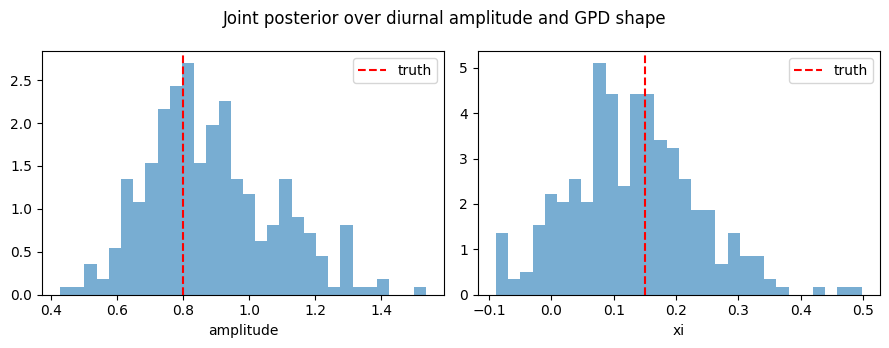

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (name, truth) in zip(axes, [("amplitude", 0.8), ("xi", XI_TRUE)]):
    ax.hist(np.asarray(post[name]), bins=30, density=True, alpha=0.6)
    ax.axvline(truth, color="red", linestyle="--", label="truth")
    ax.set_xlabel(name)
    ax.legend()
plt.suptitle("Joint posterior over diurnal amplitude and GPD shape")
plt.tight_layout()
plt.show()

Both the diurnal amplitude and the heavy-tail shape $\xi$ are identified from only six observed sequences.